In [1]:
import pandas as pd
import numpy as np
import random as rd
import torch
from collections import defaultdict

import rdkit

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.Scaffolds import MurckoScaffold

from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit import Chem
from rdkit.Chem import AllChem

# Read csv with compounds

In [2]:
data = pd.read_csv("metadata_and_label_matrix_comment.csv",index_col=0)

In [3]:
scaffolds      = defaultdict(list)
scaffolds_mols = defaultdict(list)

In [4]:
unique = data.drop_duplicates(subset="Metadata_InChI")

In [5]:
for i, row in enumerate(range(len(unique))):
    val   = unique.iloc[row]
    m     = Chem.MolFromInchi(val.Metadata_InChI)
    scaff = MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False)
    scaffolds[scaff].append(val.Metadata_JCP2022)
    scaffolds_mols[scaff].append(m)
len(scaffolds)

8775

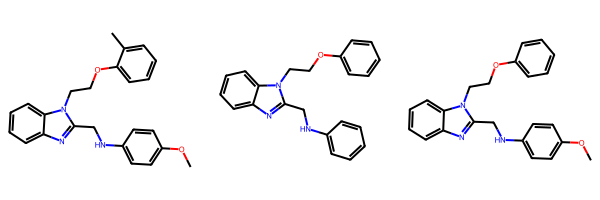

In [6]:
Chem.Draw.MolsToGridImage(scaffolds_mols["c1ccc(NCc2nc3ccccc3n2CCOc2ccccc2)cc1"])

In [7]:
def ClusterFps(fps,cutoff=0.2):
 
    # first generate the distance matrix:
    dists = []
    nfps = len(fps)
    for i in range(1,nfps):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i],fps[:i])
        dists.extend([1-x for x in sims])
 
    # now cluster the data:
    cs = Butina.ClusterData(dists,nfps,cutoff,isDistData=True)
    return cs

In [8]:
ms  = [Chem.MolFromInchi(unique.iloc[i].Metadata_InChI) for i in range(len(unique))]

In [9]:
fps = [AllChem.GetMorganFingerprintAsBitVect(x,2,1024,) for x in ms]

In [10]:
clusters = ClusterFps(fps,cutoff=0.7)

In [11]:
clu_list = list(clusters)

In [12]:
def split_data_cross_validation_structure_clustering(clusters, important_data, splits = [0,0.1667*1,0.1667*2,0.1667*3,0.1667*4,0.1667*5], split_on='compound', split_number=1):
    data = pd.read_csv("metadata_and_label_matrix_comment.csv",index_col=0)
    unique = data.drop_duplicates(subset="Metadata_InChI")
    
    unique_cmp = list(unique.Metadata_InChI.unique())
    rd.shuffle(clusters)
 
    data_splits = []
 
    cluster_index = 0
    for i in range(len(splits)):
        split_data = []

        # While the current split doesn't contain more compounds than allocated and there are still clusters left do:
        while len(split_data) <= int(splits[1] * len(unique_cmp)) and cluster_index < len(clusters):
            
            split_data.extend(important_data.iloc[list(clusters[cluster_index])]['Metadata_JCP2022'].values)
            cluster_index += 1

        data_splits.append(split_data)
        print(cluster_index)

    return data_splits
    

In [13]:
splits = split_data_cross_validation_structure_clustering(clu_list, unique)

155
351
605
770
1108
1229


In [15]:
data["split_number"] = -1
print(len(splits))
for i in range(len(splits)):
    data.loc[data.Metadata_JCP2022.isin(splits[i]),"split_number"] = i

6


In [29]:
data.to_csv("split_metadata_and_label_matrix_comment.csv")